# Geometric Content Moderation — Ablation Study

Three-configuration ablation comparing:

| Config | Model | Geometry |
|--------|-------|----------|
| **A** | DeBERTa + linear head | None (flat baseline) |
| **B** | DeBERTa + hyperbolic classifier | Poincaré ball classification |
| **C** | DeBERTa + geometric attention + hyperbolic classifier | Full geometric pipeline |

Dataset: Civil Comments (HuggingFace) → 41-node policy taxonomy

In [1]:
import subprocess, sys, os, shutil

# Colab: check GPU is enabled
try:
    import google.colab
    gpu_info = subprocess.check_output(['nvidia-smi'], stderr=subprocess.STDOUT).decode()
    if 'T4' in gpu_info or 'A100' in gpu_info or 'V100' in gpu_info or 'L4' in gpu_info:
        print(f'GPU detected.')
    else:
        print('WARNING: GPU not detected. Go to Runtime > Change runtime type > T4 GPU')
except FileNotFoundError:
    raise RuntimeError(
        'No GPU available!\n'
        'Go to: Runtime > Change runtime type > Hardware accelerator > T4 GPU\n'
        'Then restart and re-run this cell.'
    )
except ImportError:
    pass  # Not on Colab, skip GPU check

# Always fresh clone to pick up latest changes
_repo_dir = os.path.join(os.getcwd(), 'geometric-moderation')
if os.path.isdir(_repo_dir):
    shutil.rmtree(_repo_dir)
    print(f'Removed stale {_repo_dir}')

# Find project root or clone it
_candidates = [
    os.path.abspath(os.path.join(os.getcwd(), '..')),
    os.path.abspath(os.getcwd()),
]
_root = None
for _c in _candidates:
    if os.path.isfile(os.path.join(_c, 'pyproject.toml')):
        _root = _c
        break

if _root is None:
    print('Cloning from GitHub...')
    subprocess.check_call(['git', 'clone', 'https://github.com/ahb-sjsu/geometric-moderation.git'])
    _root = _repo_dir

# Add src/ to Python path directly (most reliable for notebooks)
_src = os.path.join(_root, 'src')
if _src not in sys.path:
    sys.path.insert(0, _src)
    print(f'Added {_src} to sys.path')

# Install runtime dependencies
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'scipy', 'tiktoken', 'sentencepiece', 'datasets',
                       'transformers', 'scikit-learn', 'pandas', 'batch-probe'])

import geomod
print(f'geomod loaded: {geomod.__file__}')

import torch
import numpy as np
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name} ({props.total_memory / 1e9:.1f} GB)')
else:
    print('WARNING: CUDA not available. Training will be slow on CPU.')

GPU detected.
Cloning from GitHub...
Added /content/geometric-moderation/src to sys.path
geomod loaded: /content/geometric-moderation/src/geomod/__init__.py
PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-80GB (85.1 GB)


## 1. Configuration

In [2]:
# --- Adjust these for your hardware ---
# For quick smoke test: max_samples=500, num_epochs=1
# For full run: max_samples=None, num_epochs=5

MAX_TRAIN_SAMPLES = 50000   # None for full dataset (1.8M)
MAX_EVAL_SAMPLES = 5000
NUM_EPOCHS = 5
MAX_LENGTH = 128            # 256 for full run
FP16 = torch.cuda.is_available()
ENCODER = 'microsoft/deberta-v3-base'

# Auto-detect max batch size using the most memory-intensive model (full_geometric)
if torch.cuda.is_available():
    from batch_probe import probe_batch_size
    from geomod.training.trainer import _build_model
    from geomod.training.config import AblationConfig, TrainingConfig

    _probe_config = TrainingConfig(ablation=AblationConfig.FULL_GEOMETRIC,
                                   encoder_name=ENCODER, max_length=MAX_LENGTH)
    _probe_model = _build_model(_probe_config)
    _probe_model.float().to('cuda')

    def _input_fn(bs):
        return dict(input_ids=torch.randint(0, 1000, (bs, MAX_LENGTH), device='cuda'),
                    attention_mask=torch.ones(bs, MAX_LENGTH, dtype=torch.long, device='cuda'))

    BATCH_SIZE = probe_batch_size(_probe_model, _input_fn, mode='train')
    del _probe_model, _input_fn, _probe_config
    torch.cuda.empty_cache()
    print(f'batch-probe detected max batch size: {BATCH_SIZE}')
else:
    BATCH_SIZE = 16

print(f'Train samples: {MAX_TRAIN_SAMPLES or "all"}')
print(f'Eval samples: {MAX_EVAL_SAMPLES or "all"}')
print(f'Epochs: {NUM_EPOCHS}, Batch: {BATCH_SIZE}, MaxLen: {MAX_LENGTH}')
print(f'FP16: {FP16}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Geometric bias hooks installed on 4 encoder layers
torch-probe: probing batch size (mode=train, range=[1, 4096], headroom=20%)...

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

 max=346, safe=276
batch-probe detected max batch size: 276
Train samples: 50000
Eval samples: 5000
Epochs: 5, Batch: 276, MaxLen: 128
FP16: True


## 2. Load Dataset

In [3]:
from geomod.data.datasets import CivilCommentsDataset, get_label_weights
from geomod.policy.taxonomy import default_taxonomy, PolicyTaxonomyEmbedding

taxonomy = default_taxonomy()
emb = PolicyTaxonomyEmbedding(taxonomy, embed_dim=32)

print(f'Taxonomy: {emb.num_nodes} nodes')
print(f'Loading Civil Comments...')

train_ds = CivilCommentsDataset(
    split='train', taxonomy=taxonomy, max_samples=MAX_TRAIN_SAMPLES
)
eval_ds = CivilCommentsDataset(
    split='validation', taxonomy=taxonomy, max_samples=MAX_EVAL_SAMPLES
)

print(f'Train: {len(train_ds)} samples')
print(f'Eval:  {len(eval_ds)} samples')

Taxonomy: 41 nodes
Loading Civil Comments...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/20.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1804874 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/97320 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/97320 [00:00<?, ? examples/s]

Train: 50000 samples
Eval:  5000 samples


In [4]:
# Inspect label distribution
from collections import Counter

label_counts = Counter()
for i in range(len(train_ds)):
    item = train_ds[i]
    label_counts[emb.node_names[item['taxonomy_label']]] += 1

print('Label distribution (train):')
for name, count in label_counts.most_common():
    pct = 100.0 * count / len(train_ds)
    print(f'  {name:25s} {count:6d}  ({pct:5.1f}%)')

# Class weights
class_weights = get_label_weights(train_ds)
active_classes = ((class_weights > 0) & (class_weights < 100.0)).sum().item()
print(f'\nActive classes (weight > 0 and < 100): {active_classes}/{emb.num_nodes}')

Label distribution (train):
  benign                     46590  ( 93.2%)
  harassment                  2143  (  4.3%)
  violence                     504  (  1.0%)
  explicit_sexual              308  (  0.6%)
  hate_speech                  207  (  0.4%)
  threats                      141  (  0.3%)
  sexual_content               106  (  0.2%)
  graphic_violence               1  (  0.0%)

Active classes (weight > 0 and < 100): 8/41


## 3. Run Ablation

In [5]:
from geomod.training.config import AblationConfig, TrainingConfig
from geomod.training.trainer import ModerationTrainer

configs = {
    'flat_baseline': AblationConfig.FLAT_BASELINE,
    'hyperbolic_head': AblationConfig.HYPERBOLIC_HEAD,
    'full_geometric': AblationConfig.FULL_GEOMETRIC,
}

all_results = {}
all_histories = {}

for name, ablation in configs.items():
    print(f'\n{"=" * 60}')
    print(f'Config: {name}')
    print(f'{"=" * 60}')

    config = TrainingConfig(
        ablation=ablation,
        encoder_name=ENCODER,
        num_epochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        eval_batch_size=BATCH_SIZE * 2,
        max_length=MAX_LENGTH,
        fp16=FP16,
        max_train_samples=MAX_TRAIN_SAMPLES,
        max_eval_samples=MAX_EVAL_SAMPLES,
        output_dir=f'outputs/{name}',
    )

    trainer = ModerationTrainer(
        config=config,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        class_weights=class_weights,
        label_names=emb.node_names,
    )

    history = trainer.train()
    final_metrics = history['eval_metrics'][-1]

    all_results[name] = final_metrics
    all_histories[name] = history

    print(f'\nFinal — acc: {final_metrics["accuracy"]:.4f}  '
          f'macro_f1: {final_metrics["macro_f1"]:.4f}  '
          f'weighted_f1: {final_metrics["weighted_f1"]:.4f}')
    if 'severity_spearman' in final_metrics:
        print(f'         severity_rho: {final_metrics["severity_spearman"]:.4f}')

    # Free GPU memory between configs
    del trainer
    torch.cuda.empty_cache() if torch.cuda.is_available() else None


Config: flat_baseline


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Geometric bias hooks installed on 4 encoder layers


/content/geometric-moderation/src/geomod/training/trainer.py:269: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  self.scheduler.step()



Final — acc: 0.6176  macro_f1: 0.1197  weighted_f1: 0.7135
         severity_rho: -0.0342


## 4. Compare Results

In [6]:
from geomod.training.metrics import compute_ablation_comparison
import pandas as pd

comparison = compute_ablation_comparison(all_results)

# Build summary table
summary_cols = ['accuracy', 'macro_f1', 'weighted_f1', 'severity_spearman', 'severity_mse',
                'delta_accuracy', 'delta_macro_f1', 'delta_weighted_f1', 'delta_severity_spearman']

rows = []
for config_name in ['flat_baseline', 'hyperbolic_head', 'full_geometric']:
    m = comparison.get(config_name, {})
    row = {'config': config_name}
    for col in summary_cols:
        if col in m:
            row[col] = m[col]
    rows.append(row)

df = pd.DataFrame(rows).set_index('config')
print(df.to_string(float_format='%.4f'))

                 accuracy  macro_f1  weighted_f1  severity_spearman  severity_mse  delta_accuracy  delta_macro_f1  delta_weighted_f1
config                                                                                                                              
flat_baseline      0.8762    0.3191       0.8968                NaN           NaN             NaN             NaN                NaN
hyperbolic_head    0.1990    0.0536       0.3153            -0.0368        0.1773         -0.6772         -0.2655            -0.5815
full_geometric     0.6176    0.1197       0.7135            -0.0342        0.1057         -0.2586         -0.1994            -0.1833


## 5. Training Curves

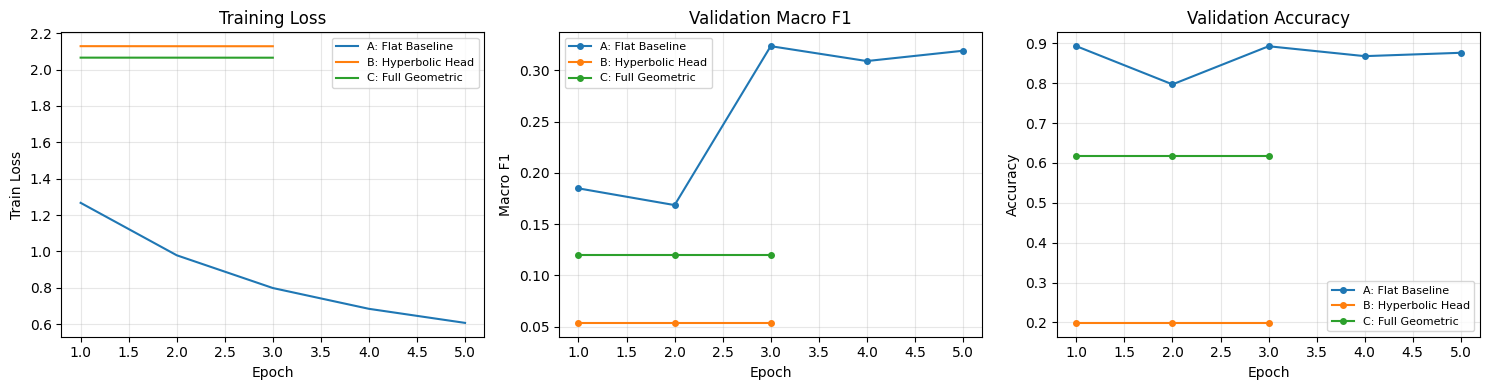

Saved: ablation_curves.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = {'flat_baseline': '#1f77b4', 'hyperbolic_head': '#ff7f0e', 'full_geometric': '#2ca02c'}
labels = {'flat_baseline': 'A: Flat Baseline', 'hyperbolic_head': 'B: Hyperbolic Head', 'full_geometric': 'C: Full Geometric'}

# Loss
ax = axes[0]
for name, hist in all_histories.items():
    epochs = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs, hist['train_loss'], color=colors[name], label=labels[name])
ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss')
ax.set_title('Training Loss')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Macro F1
ax = axes[1]
for name, hist in all_histories.items():
    f1s = [m['macro_f1'] for m in hist['eval_metrics']]
    epochs = range(1, len(f1s) + 1)
    ax.plot(epochs, f1s, color=colors[name], label=labels[name], marker='o', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro F1')
ax.set_title('Validation Macro F1')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Accuracy
ax = axes[2]
for name, hist in all_histories.items():
    accs = [m['accuracy'] for m in hist['eval_metrics']]
    epochs = range(1, len(accs) + 1)
    ax.plot(epochs, accs, color=colors[name], label=labels[name], marker='o', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Validation Accuracy')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ablation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_curves.png')

## 6. Severity Calibration

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Geometric bias hooks installed on 4 encoder layers


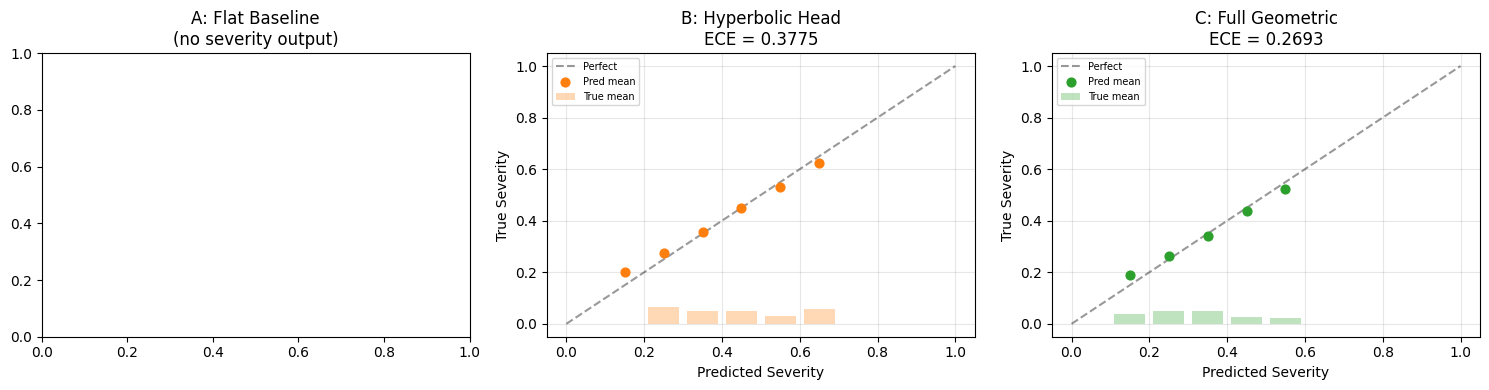

Saved: severity_calibration.png


In [8]:
from geomod.training.metrics import compute_severity_calibration
from torch.utils.data import DataLoader
from geomod.data.tokenization import ModerationTokenizer, make_collate_fn
from geomod.training.trainer import _build_model

# Reload best models and compute severity calibration
tokenizer = ModerationTokenizer(model_name=ENCODER, max_length=MAX_LENGTH)
collate = make_collate_fn(tokenizer)
eval_loader = DataLoader(eval_ds, batch_size=BATCH_SIZE * 2, shuffle=False, collate_fn=collate)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, ablation) in enumerate(configs.items()):
    ckpt_path = f'outputs/{name}/best_model.pt'
    if not os.path.exists(ckpt_path):
        print(f'Skipping {name} — no checkpoint found')
        continue

    config = TrainingConfig(ablation=ablation, encoder_name=ENCODER, max_length=MAX_LENGTH)
    model = _build_model(config)
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    model.float()
    model.to(device)
    model.eval()

    sev_preds, sev_trues = [], []
    with torch.no_grad():
        for batch in eval_loader:
            out = model(input_ids=batch['input_ids'].to(device),
                        attention_mask=batch['attention_mask'].to(device))
            if 'severity' in out:
                sev_preds.append(out['severity'].squeeze(-1).cpu().numpy())
                sev_trues.append(batch['severity_target'].numpy())

    if not sev_preds:
        axes[idx].set_title(f'{labels[name]}\n(no severity output)')
        continue

    sev_pred = np.concatenate(sev_preds)
    sev_true = np.concatenate(sev_trues)
    cal = compute_severity_calibration(sev_pred, sev_true, n_bins=10)

    ax = axes[idx]
    bin_centers = (cal['bin_edges'][:-1] + cal['bin_edges'][1:]) / 2
    mask = cal['bin_counts'] > 0
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect')
    ax.bar(bin_centers[mask], cal['bin_means_true'][mask], width=0.08, alpha=0.3,
           color=colors[name], label='True mean')
    ax.scatter(bin_centers[mask], cal['bin_means_pred'][mask], color=colors[name],
              s=40, zorder=5, label='Pred mean')
    ax.set_xlabel('Predicted Severity')
    ax.set_ylabel('True Severity')
    ax.set_title(f'{labels[name]}\nECE = {cal["ece"]:.4f}')
    ax.legend(fontsize=7)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

plt.tight_layout()
plt.savefig('severity_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: severity_calibration.png')

## 7. Per-Class F1 Breakdown

In [9]:
# Show per-class F1 for each config (only active classes)
per_class_rows = []
for name in ['flat_baseline', 'hyperbolic_head', 'full_geometric']:
    metrics = all_results.get(name, {})
    row = {'config': labels.get(name, name)}
    for key, val in metrics.items():
        if key.startswith('f1_'):
            class_name = key[3:]
            row[class_name] = val
    per_class_rows.append(row)

df_class = pd.DataFrame(per_class_rows).set_index('config')
# Only show columns with non-zero values
active = df_class.columns[df_class.max() > 0]
if len(active) > 0:
    print(df_class[active].to_string(float_format='%.3f'))
else:
    print('No per-class F1 data (all classes may be collapsed to benign with small samples)')
    print(df_class.to_string(float_format='%.3f'))

                    violence  threats  hate_speech  sexual_content  explicit_sexual  harassment  benign
config                                                                                                 
A: Flat Baseline       0.099    0.045        0.251           0.000            0.410       0.491   0.938
B: Hyperbolic Head     0.017    0.000        0.010           0.000            0.000       0.007   0.340
C: Full Geometric      0.000    0.000        0.000           0.003            0.000       0.068   0.768


## 8. Poincar\u00e9 Ball Embedding Visualization

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Geometric bias hooks installed on 4 encoder layers


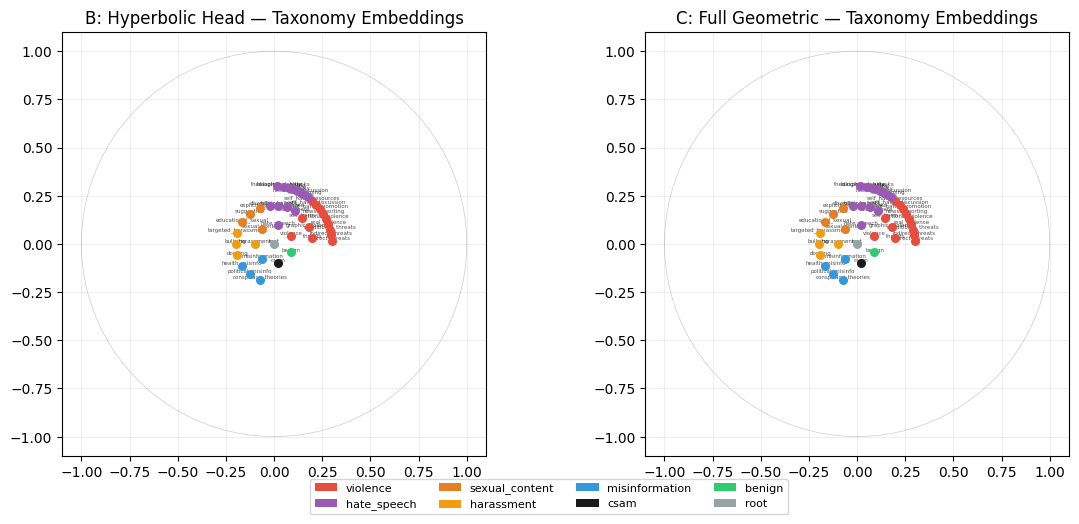

Saved: taxonomy_embeddings.png


In [10]:
# Visualize the learned taxonomy embeddings in 2D (first 2 dims of Poincare ball)
# Only for configs B and C which have taxonomy embeddings

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Color by top-level category
top_level = {
    'violence': '#e74c3c', 'hate_speech': '#9b59b6', 'sexual_content': '#e67e22',
    'harassment': '#f39c12', 'misinformation': '#3498db',
    'csam': '#1a1a1a', 'benign': '#2ecc71', 'root': '#95a5a6'
}

for idx, name in enumerate(['hyperbolic_head', 'full_geometric']):
    ckpt_path = f'outputs/{name}/best_model.pt'
    if not os.path.exists(ckpt_path):
        axes[idx].set_title(f'{labels[name]} — no checkpoint')
        continue

    ablation = configs[name]
    config = TrainingConfig(ablation=ablation, encoder_name=ENCODER, max_length=MAX_LENGTH)
    model = _build_model(config)
    model.load_state_dict(torch.load(ckpt_path, map_location='cpu', weights_only=True))
    model.float()

    # Extract taxonomy embeddings
    tax_emb = model.classifier.taxonomy_emb
    with torch.no_grad():
        points = tax_emb.forward().numpy()  # (num_nodes, hyp_dim)

    ax = axes[idx]
    # Draw unit circle (Poincare ball boundary)
    theta = np.linspace(0, 2 * np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), 'k-', alpha=0.2, linewidth=0.5)

    for i, node_name in enumerate(tax_emb.node_names):
        # Find which top-level category this belongs to
        color = '#95a5a6'  # default gray
        for cat, c in top_level.items():
            cat_node = taxonomy.find(cat)
            if cat_node and cat_node.find(node_name):
                color = c
                break
            if node_name == cat:
                color = c
                break

        ax.scatter(points[i, 0], points[i, 1], c=color, s=30, zorder=5)
        ax.annotate(node_name, (points[i, 0], points[i, 1]),
                   fontsize=4, alpha=0.7, ha='center', va='bottom')

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.set_title(f'{labels[name]} — Taxonomy Embeddings')
    ax.grid(alpha=0.2)

    del model

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=n) for n, c in top_level.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=8,
          bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('taxonomy_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: taxonomy_embeddings.png')

## Summary

Key metrics to compare across the three configurations:

- **Macro F1** — measures performance across all categories (not dominated by benign)
- **Severity Spearman ρ** — how well does severity ranking match the taxonomy hierarchy
- **ECE** — calibration of severity scores
- **Per-class F1** — which specific violation types improve with geometry

Expected pattern: C ≥ B > A on macro F1 and severity correlation, with the geometric
models better separating hierarchically related categories (e.g., threats vs. violence).